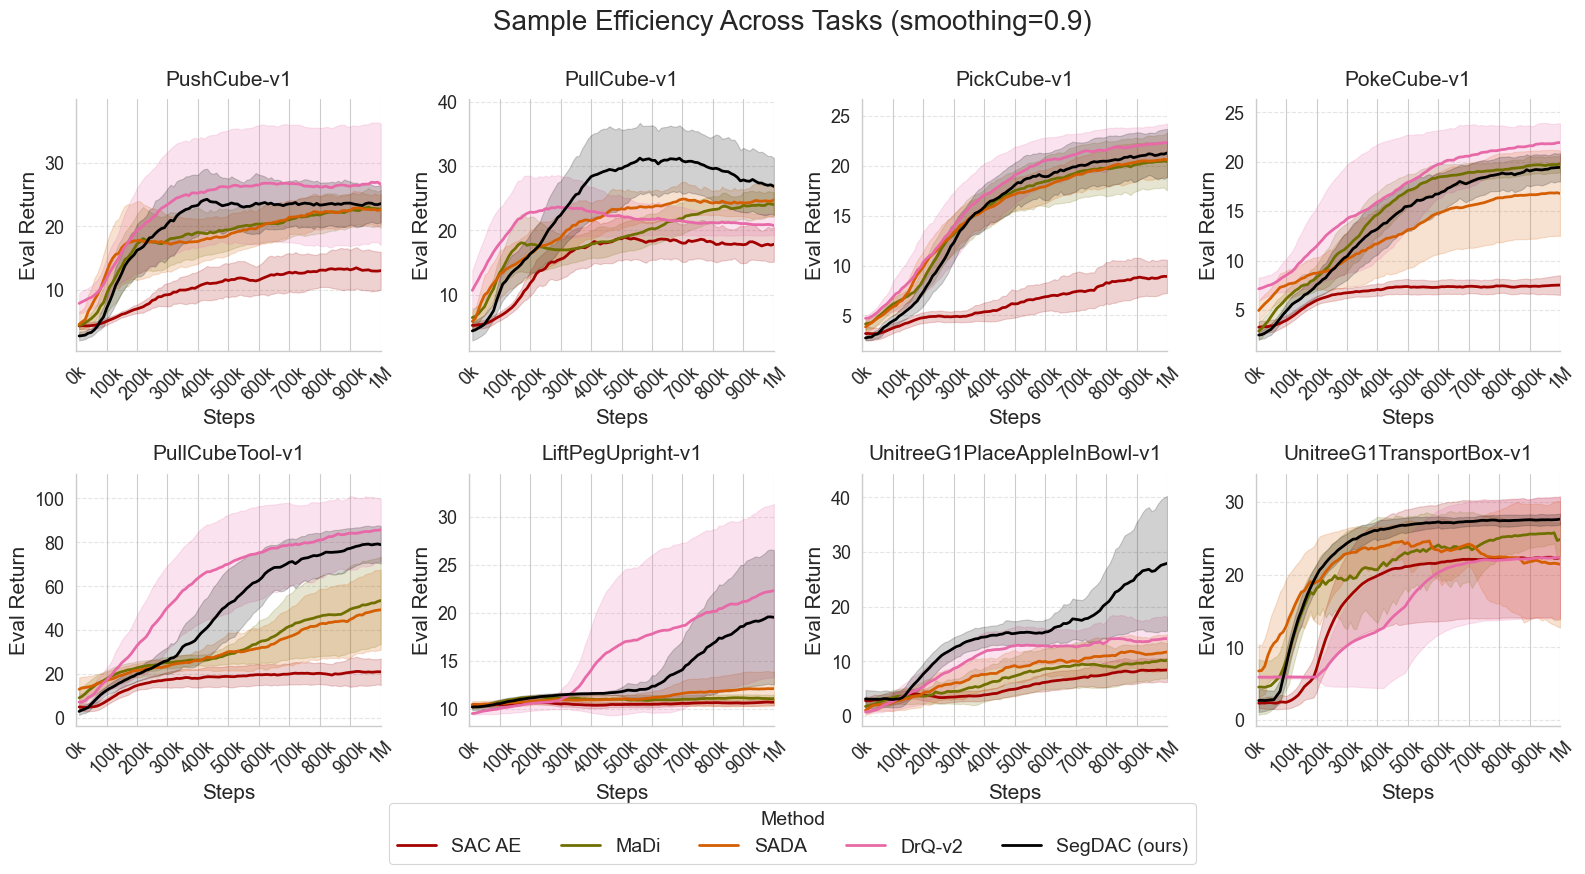

In [38]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import MultipleLocator, FuncFormatter

from comet_ml.query import Parameter, Tag
import comet_ml

PROJECT_NAME = "segdac"
WORKSPACE_NAME = "alexandrebrown"
# Smoothing constant for running average. Use 0 for raw values, e.g. SMOOTHING_ALPHA = 0 (no smoothing), SMOOTHING_ALPHA = 0.5 (50% smoothing)
SMOOTHING_ALPHA = 0.9

comet_ml.login()

api = comet_ml.API()

EXPECTED_NB_SEEDS = 5


tasks = [
    "PushCube-v1",
    "PullCube-v1",
    "PickCube-v1",
    "PokeCube-v1",
    "PullCubeTool-v1",
    "LiftPegUpright-v1",
    "UnitreeG1PlaceAppleInBowl-v1",
    "UnitreeG1TransportBox-v1",
]

logged_task_names = {
    "PushCube-v1": ["PushCube-v1", "PushCubeFixed-v1"],
    "PullCube-v1": ["PullCube-v1"],
    "PickCube-v1": ["PickCube-v1", "PickCubeVisual-v1"],
    "PokeCube-v1": ["PokeCube-v1"],
    "PullCubeTool-v1": ["PullCubeTool-v1"],
    "LiftPegUpright-v1": ["LiftPegUpright-v1"],
    "UnitreeG1PlaceAppleInBowl-v1": ["UnitreeG1PlaceAppleInBowl-v1"],
    "UnitreeG1TransportBox-v1": ["UnitreeG1TransportBox-v1"],
}

color_map = {
    # "sac_state": "#009E73",
    "sac_ae": "#A30000",
    "madi": "#707000",
    "sada": "#D55E00",
    "drqv2": "#e869a7",
    "segdac_sac_sam_enc_decoder_q_cond": "#000000",
    # "segdac_decoder_q_value_change_aux_critic": "#0008FF",
}

algo_name_mapping = {
    # "sac_state": "SAC State",
    "sac_ae": "SAC AE",
    "madi": "MaDi",
    "sada": "SADA",
    "drqv2": "DrQ-v2",
    "segdac_sac_sam_enc_decoder_q_cond": "SegDAC (ours)",
    # "segdac_decoder_q_value_change_aux_critic": "SegDAC + Aux (ours)",
}

output_eval_results_folder = Path("results/eval")
output_plots_folder = output_eval_results_folder / Path("plots")
output_plots_folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="paper", style="whitegrid", font_scale=1.2)


def xfmt(x, pos):
    if x >= 1_000_000:
        return f"{int(x/1_000_000)}M"
    else:
        return f"{int(x/1000)}k"

def smooth_curve(curve, alpha):
    """
    Smooth a curve using an exponential moving average, matching CometML's formula.
    alpha: The smoothing factor (0=raw, 1=max smoothing).
    """
    if alpha == 0:
        return curve
    
    # The formula is inverted to match the intuitive behavior where a higher alpha means more smoothing.
    beta = alpha
    alpha = 1 - beta

    smoothed = np.zeros_like(curve)
    smoothed[0] = curve[0]
    for i in range(1, len(curve)):
        smoothed[i] = alpha * curve[i] + beta * smoothed[i - 1]
    return smoothed


# We disable sharey so that each subplot can have its own y–range.
nb_cols=4
fig, axes = plt.subplots(2, nb_cols, figsize=(16, 9), sharex=True, sharey=False)
plt.subplots_adjust(wspace=0.18, hspace=0.18, left=0.07, right=0.98, top=0.90, bottom=0.18)

for idx, task_name in enumerate(tasks):
    output_data = {}
    task_experiments = []
    for logged_task in logged_task_names[task_name]:
        baselines_experiments = api.query(
            WORKSPACE_NAME,
            PROJECT_NAME,
            (Parameter("env|id") == logged_task) & Tag("baseline"),
        )
        segdac_experiments = api.query(
            WORKSPACE_NAME,
            PROJECT_NAME,
            (Parameter("env|id") == logged_task) & Tag("paper-result"),
        )
        task_experiments += (baselines_experiments + segdac_experiments)

    nb_algos = len(algo_name_mapping.keys())
    expected_number_of_runs = EXPECTED_NB_SEEDS * nb_algos
    assert (
        len(task_experiments) == expected_number_of_runs
    ), f"Found {len(task_experiments)} experiments for task {task_name}, expected {expected_number_of_runs}!"

    algo_to_task_metrics = {}
    for algo_name in algo_name_mapping.keys():
        algo_experiments = []
        for experiment in task_experiments:
            if algo_name.lower() in experiment.get_parameters_summary("algo|name")["valueCurrent"].lower():
                algo_experiments.append(experiment)
        assert (
            len(algo_experiments) == EXPECTED_NB_SEEDS
        ), f"Found {len(algo_experiments)} experiments for {algo_name}, expected {EXPECTED_NB_SEEDS} for task {task_name}!"

        algo_task_seeds_returns = []
        algo_task_seeds_steps = []
        for algo_experiment in algo_experiments:
            unique_experiment_returns = {}
            experiment_returns = sorted(
                algo_experiment.get_metrics("eval_return"), key=lambda x: x["step"]
            )
            for exp_return in experiment_returns:
                step = int(exp_return["step"])
                if step not in unique_experiment_returns:
                    unique_experiment_returns[step] = float(exp_return["metricValue"])
            logged_steps = sorted(unique_experiment_returns.keys())
            algo_task_seeds_returns.append([unique_experiment_returns[s] for s in logged_steps])
            algo_task_seeds_steps.append(logged_steps)

        algo_task_seeds_returns = np.stack(algo_task_seeds_returns)
        algo_task_return_means = np.mean(algo_task_seeds_returns, axis=0)
        algo_task_return_stds = np.std(algo_task_seeds_returns, axis=0)

        output_data[algo_name] = {}
        for seed in range(algo_task_seeds_returns.shape[0]):
            output_data[algo_name][f"seed_{seed+1}"] = {
                "return": algo_task_seeds_returns[seed].tolist(),
                "step": algo_task_seeds_steps[seed],
            }
        output_data[algo_name]["aggregated"] = {
            "return_mean": algo_task_return_means.tolist(),
            "return_std": algo_task_return_stds.tolist(),
            "step": algo_task_seeds_steps[-1],
        }

        algo_to_task_metrics[algo_name] = {
            "return_mean": algo_task_return_means,
            "return_std": algo_task_return_stds,
        }

    ax = axes[idx // nb_cols, idx % nb_cols]
    last_step = algo_task_seeds_steps[0][-1]
    nb_ticks = 10
    ax.xaxis.set_major_locator(MultipleLocator(last_step // nb_ticks))
    ax.xaxis.set_major_formatter(FuncFormatter(xfmt))
    step_interval = algo_task_seeds_steps[0][-1] - algo_task_seeds_steps[0][-2]
    x_ticks = np.arange(0, last_step + step_interval, step_interval)[1:]

    # Track maximum of (smoothed mean + smoothed std) for this task
    local_ymax = 0
    for algo_name in algo_name_mapping.keys():
        color = color_map[algo_name]
        return_means = algo_to_task_metrics[algo_name]["return_mean"]
        return_stds  = algo_to_task_metrics[algo_name]["return_std"]
        # Apply smoothing
        return_means = smooth_curve(return_means, SMOOTHING_ALPHA)
        return_stds  = smooth_curve(return_stds, SMOOTHING_ALPHA)
        ax.plot(x_ticks, return_means, label=algo_name_mapping[algo_name], color=color, linewidth=2)
        lower = return_means - return_stds
        upper = return_means + return_stds
        ax.fill_between(x_ticks, lower, upper, color=color, alpha=0.18)
        local_ymax = max(local_ymax, np.max(upper))

    ax.set_ylabel("Eval Return", fontsize=15)
    ax.yaxis.set_tick_params(labelleft=True)

    ax.set_xlabel("Steps", fontsize=15)
    ax.xaxis.set_tick_params(labelbottom=True)
    for label in ax.get_xticklabels():
        label.set_rotation(45)

    ax.set_title(task_name, fontsize=15, pad=10)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_xlim(0, last_step)
    
    # Adjust the y-limit based on the maximum envelope from the data
    ax.set_ylim(ax.get_ylim()[0], local_ymax * 1.1)
    ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
    # Ensure we keep the left spine (y-axis) by setting left=False
    # The `trim=True` argument was causing an IndexError when no y-ticks were in range.
    # Removing it is the simplest fix and maintains the desired plot appearance.
    sns.despine(fig=fig, ax=ax, top=True, right=True, left=False)
    
    with open(output_eval_results_folder / Path(task_name.lower() + "_eval_data.json"), "w") as f:
        json.dump(output_data, f)

# Remove legends from individual axes if any exist
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.legend_.remove()

# Add one legend at the bottom
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Method", fontsize=14, title_fontsize=14,
    loc="lower center", ncol=len(algo_name_mapping), frameon=True, bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle(f"Sample Efficiency Across Tasks (smoothing={SMOOTHING_ALPHA})", fontsize=20, y=0.97)
fig.tight_layout(rect=(0, 0.07, 1, 0.97))

out_fname = output_plots_folder / Path("all_tasks_sample_efficiency.pdf")
fig.savefig(out_fname)
plt.show()

with open(output_eval_results_folder / Path(task_name.lower() + "_eval_data.json"), "w") as f:
    json.dump(output_data, f)

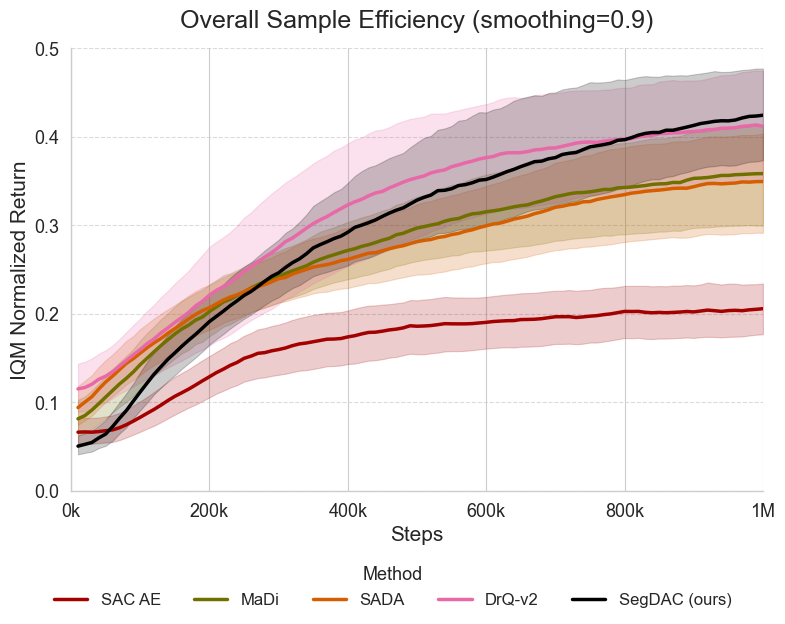

In [ ]:
from scipy.stats import trim_mean
import numpy as np

# 1. Define Max Episode Lengths for normalization based on the provided table
task_max_episode_lengths = {
    "PushCube-v1": 50,
    "PullCube-v1": 50,
    "PickCube-v1": 50,
    "PokeCube-v1": 50,
    "PullCubeTool-v1": 100,
    "LiftPegUpright-v1": 50,
    "UnitreeG1PlaceAppleInBowl-v1": 100,
    "UnitreeG1TransportBox-v1": 100,
}

def bootstrap_iqm_ci(pooled_runs, n_bootstraps=2000, ci_level=0.95):
    """Calculates the confidence interval for the IQM using bootstrapping."""
    num_runs = pooled_runs.shape[0]
    
    # Store the bootstrapped IQM values
    bootstrapped_iqms = []
    
    for _ in range(n_bootstraps):
        # Sample run indices with replacement
        indices = np.random.choice(num_runs, size=num_runs, replace=True)
        bootstrap_sample = pooled_runs[indices]
        
        # Calculate the IQM for this bootstrap sample
        bootstrapped_iqms.append(trim_mean(bootstrap_sample, proportiontocut=0.25, axis=0))
        
    bootstrapped_iqms = np.array(bootstrapped_iqms)
    
    # Calculate the confidence interval from the percentiles of the bootstrapped IQMs
    lower_percentile = (1.0 - ci_level) / 2.0 * 100
    upper_percentile = (1.0 - (1.0 - ci_level) / 2.0) * 100
    
    lower_bound = np.percentile(bootstrapped_iqms, lower_percentile, axis=0)
    upper_bound = np.percentile(bootstrapped_iqms, upper_percentile, axis=0)
    
    return lower_bound, upper_bound

# 2. Calculate normalized returns for all runs
agg_algo_returns = {algo_name: [] for algo_name in algo_name_mapping.keys()}

for task_name in tasks:
    json_path = output_eval_results_folder / Path(task_name.lower() + "_eval_data.json")
    with open(json_path, "r") as f:
        task_data = json.load(f)
    
    max_episode_length = task_max_episode_lengths[task_name]
    
    for algo_name in algo_name_mapping.keys():
        all_seed_returns = []
        for seed in range(EXPECTED_NB_SEEDS):
            seed_returns = np.array(task_data[algo_name][f"seed_{seed+1}"]["return"])
            normalized_returns = seed_returns / max_episode_length
            all_seed_returns.append(normalized_returns)
        
        agg_algo_returns[algo_name].append(np.stack(all_seed_returns))

# 3. Reshape data and plot the aggregated results using IQM and bootstrapped CIs
fig_agg, ax_agg = plt.subplots(1, 1, figsize=(8, 6))

for algo_name, task_returns_list in agg_algo_returns.items():
    # Stack to get shape (num_tasks, num_seeds, num_steps)
    stacked_task_returns = np.stack(task_returns_list)
    
    # Reshape to pool all runs (tasks * seeds) together. Shape: (num_runs, num_steps)
    num_steps = stacked_task_returns.shape[2]
    pooled_runs = stacked_task_returns.transpose(1, 0, 2).reshape(-1, num_steps)
    
    # Calculate IQM across all pooled runs
    iqm_returns = trim_mean(pooled_runs, proportiontocut=0.25, axis=0)
    
    # Calculate 95% confidence interval using bootstrapping
    lower_bound, upper_bound = bootstrap_iqm_ci(pooled_runs)
    
    # Apply smoothing to the IQM and its confidence interval
    smoothed_iqm = smooth_curve(iqm_returns, SMOOTHING_ALPHA)
    smoothed_lower = smooth_curve(lower_bound, SMOOTHING_ALPHA)
    smoothed_upper = smooth_curve(upper_bound, SMOOTHING_ALPHA)
    
    color = color_map[algo_name]
    # Plot the smoothed IQM
    ax_agg.plot(x_ticks, smoothed_iqm, label=algo_name_mapping[algo_name], color=color, linewidth=2.5)
    
    # Fill the smoothed confidence interval
    ax_agg.fill_between(x_ticks, smoothed_lower, smoothed_upper, color=color, alpha=0.2)

ax_agg.set_title(f"Overall Sample Efficiency (smoothing={SMOOTHING_ALPHA})", fontsize=18, pad=15)
ax_agg.set_xlabel("Steps", fontsize=15)
ax_agg.set_ylabel("IQM Normalized Return", fontsize=15)
ax_agg.xaxis.set_major_formatter(FuncFormatter(xfmt))
ax_agg.tick_params(axis='both', labelsize=13)
ax_agg.set_xlim(0, x_ticks[-1])
ax_agg.set_ylim(0, 0.5) # Set y-limit to [0, 0.5]
ax_agg.grid(True, which='major', axis='y', linestyle='--', alpha=0.7)
sns.despine(fig=fig_agg, ax=ax_agg)

# Create a legend for the aggregated plot
handles, labels = ax_agg.get_legend_handles_labels()
fig_agg.legend(handles, labels, title="Method", fontsize=12, title_fontsize=13, loc="lower center", ncol=len(algo_name_mapping), bbox_to_anchor=(0.5, -0.05), frameon=False)

fig_agg.tight_layout(rect=(0, 0.05, 1, 1))

# Save the aggregated plot
agg_out_fname = output_plots_folder / Path("aggregated_iqm_normalized_return_smoothed.pdf")
fig_agg.savefig(agg_out_fname, bbox_inches='tight')
plt.show()